In [ ]:
# ====== 1. Upload File CSV ======
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving persebaran_exypn_pivot (1).csv to persebaran_exypn_pivot (1).csv


In [68]:
# Ambil nama file yang di-upload
filename = list(uploaded.keys())[0]
print("File uploaded:", filename)

# ====== 2. Baca CSV ======
df = pd.read_csv(filename)
df['produk'] = df['produk'].replace({
    "Yayle Exypnost 120 ml": "Madurasa 120 ml",
    "Yayle Exypnost 200 ml": "Madurasa 200 ml"
})

df.head()

File uploaded: persebaran_exypn_pivot (1).csv


,kota_normal,produk,7,8,9,10,total
0,Aceh Barat,Madurasa 120 ml,103,60,50,55,268
1,Aceh Barat,Madurasa 200 ml,77,23,40,29,169
2,Aceh Barat Daya,Madurasa 120 ml,73,51,35,40,199
3,Aceh Barat Daya,Madurasa 200 ml,78,31,21,27,157
4,Aceh Besar,Madurasa 120 ml,99,61,41,50,251


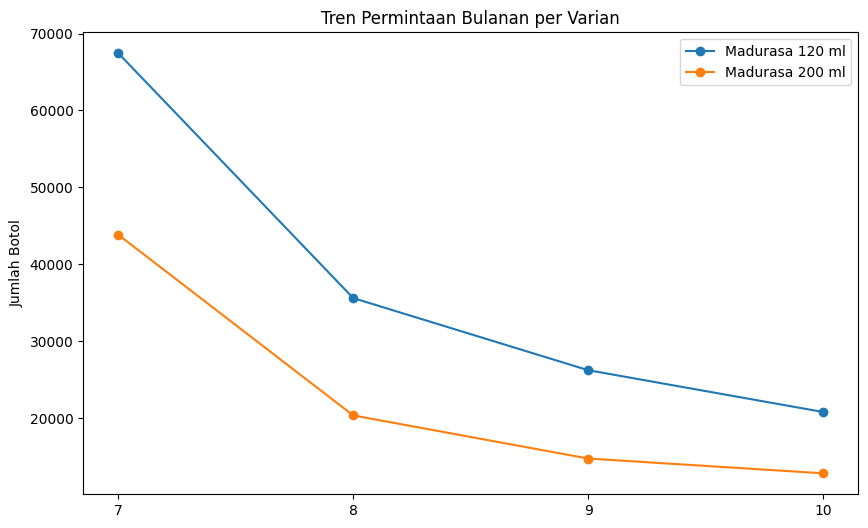

In [37]:
bulan_cols = ['7','8','9','10']

trend_varian = df.groupby("produk")[bulan_cols].sum()
trend_varian
plt.figure(figsize=(10,6))
for var in trend_varian.index:
    plt.plot(bulan_cols, trend_varian.loc[var], marker='o', label=var)

plt.title("Tren Permintaan Bulanan per Varian")
plt.ylabel("Jumlah Botol")
plt.legend()
plt.show()


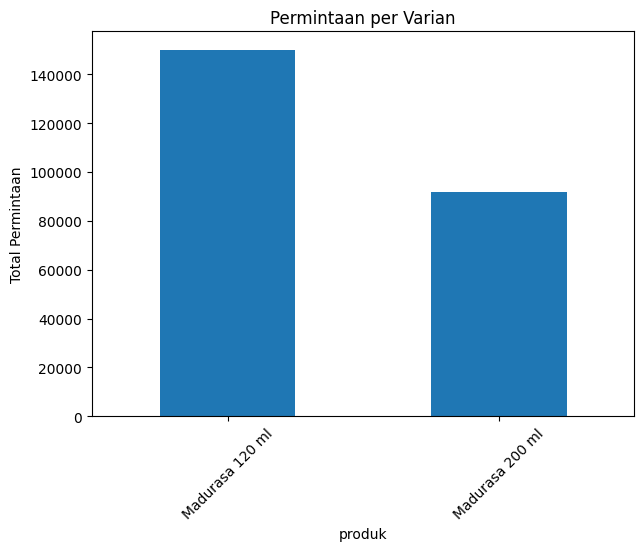

In [35]:
permintaan_varian = df.groupby("produk")['total'].sum().sort_values(ascending=False)
permintaan_varian
plt.figure(figsize=(7,5))
permintaan_varian.plot(kind='bar')
plt.title("Permintaan per Varian")
plt.ylabel("Total Permintaan")
plt.xticks(rotation=45)
plt.show()


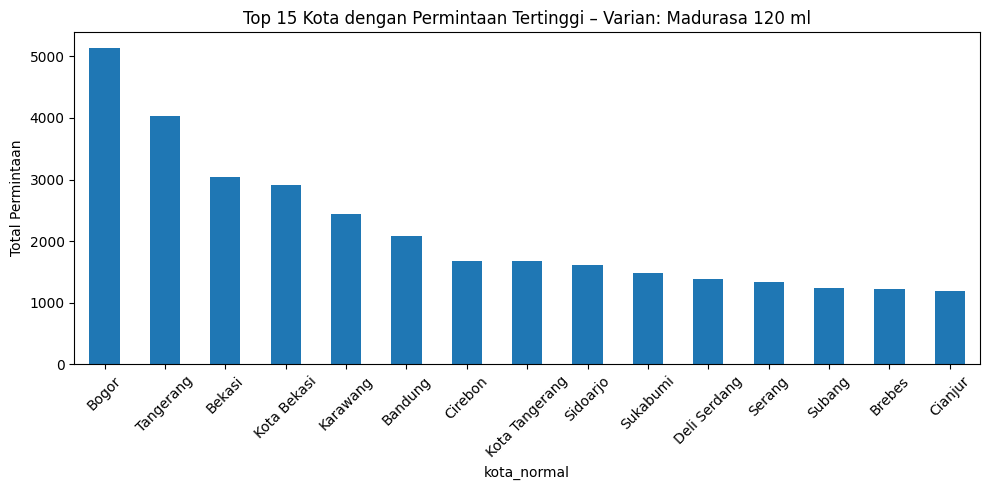

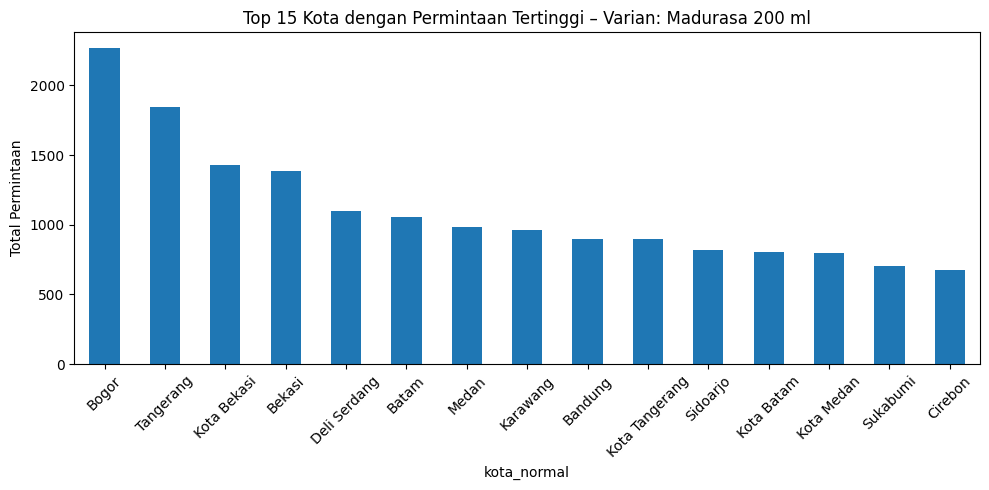

In [36]:
# Ambil daftar varian
variants = df['produk'].unique()
variants
for var in variants:
    df_var = df[df['produk'] == var]

    permintaan_kota_var = (
        df_var.groupby("kota_normal")['total']
        .sum()
        .sort_values(ascending=False)
    )

    # Plot
    plt.figure(figsize=(10,5))
    permintaan_kota_var.head(15).plot(kind='bar')
    plt.title(f"Top 15 Kota dengan Permintaan Tertinggi – Varian: {var}")
    plt.ylabel("Total Permintaan")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

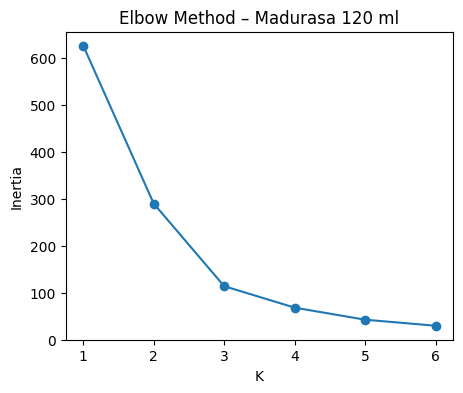

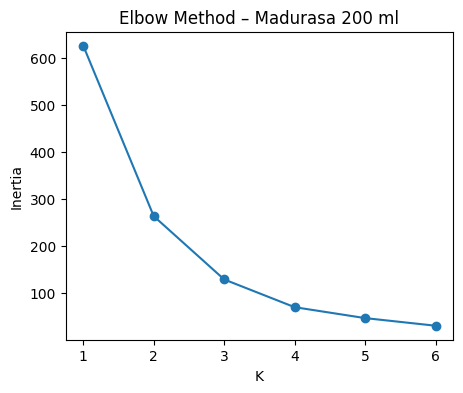

In [40]:
# ================================
# 1. FILTER DATA PER PRODUK
# ================================

produk_120 = df[df['produk'] == "Madurasa 120 ml"].copy()
produk_200 = df[df['produk'] == "Madurasa 200 ml"].copy()

# ================================
# 2. AGREGASI PER KOTA
# ================================
def prep_data_per_produk(df_produk):
    pivot = df_produk.pivot_table(
        index="kota_normal",
        values="total",
        aggfunc="sum"
    ).fillna(0)

    # rename kolom biar jelas
    pivot = pivot.rename(columns={"total": "total_produk"})
    return pivot

pivot_120 = prep_data_per_produk(produk_120)
pivot_200 = prep_data_per_produk(produk_200)

# ================================
# 3. STANDARDISASI
# ================================
scaler = StandardScaler()

X120 = scaler.fit_transform(pivot_120)
X200 = scaler.fit_transform(pivot_200)

# ================================
# 4. FUNGSI ELBOW METHOD
# ================================
def elbow_plot(X, title):
    inertia = []
    K = range(1, 7)
    for k in K:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inertia.append(km.inertia_)

    plt.figure(figsize=(5,4))
    plt.plot(K, inertia, marker="o")
    plt.xlabel("K")
    plt.ylabel("Inertia")
    plt.title(f"Elbow Method – {title}")
    plt.show()

# ================================
# 5. TAMPILKAN ELBOW PER PRODUK
# ================================
elbow_plot(X120, "Madurasa 120 ml")
elbow_plot(X200, "Madurasa 200 ml")



 PCA + KMEANS PRODUK: Madurasa 120 ml



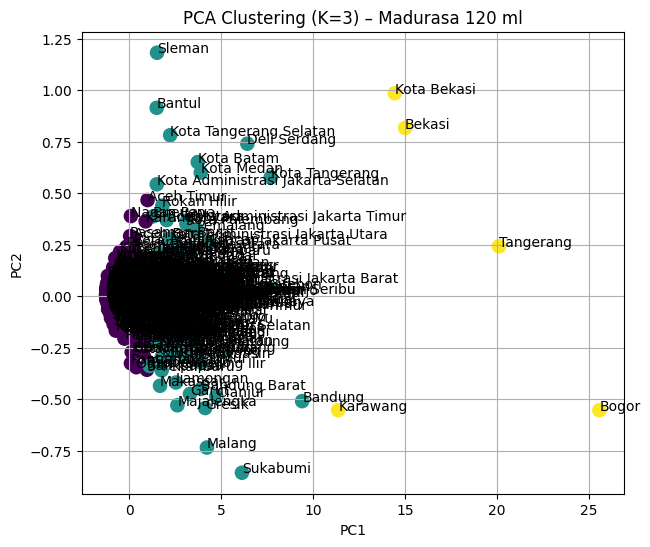


 PCA + KMEANS PRODUK: Madurasa 200 ml



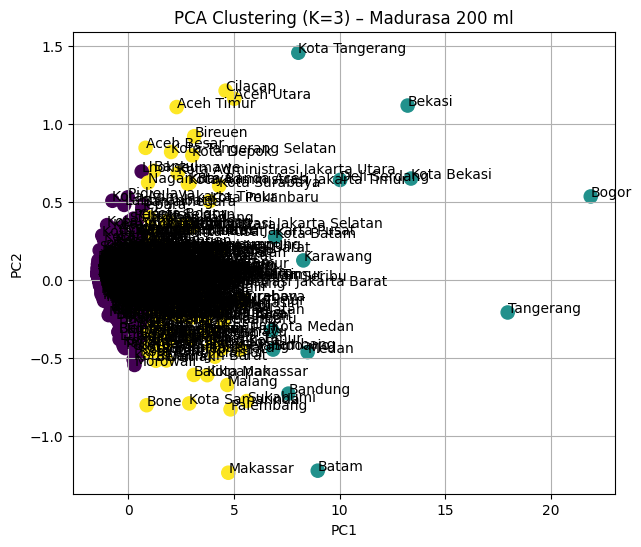

In [41]:
def pca_kmeans_plot(df_produk, nama_produk, k=3):

    print(f"\n==============================")
    print(f" PCA + KMEANS PRODUK: {nama_produk}")
    print(f"==============================\n")

    # --------------------------------------
    # 1. AGREGASI PER KOTA
    # --------------------------------------
    pivot = df_produk.pivot_table(
        index="kota_normal",
        values=["7","8","9","10","total"],   # pakai fitur lengkap biar PCA bisa
        aggfunc="sum"
    ).fillna(0)

    X = pivot.values

    # --------------------------------------
    # 2. STANDARDISASI
    # --------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --------------------------------------
    # 3. K-MEANS
    # --------------------------------------
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    pivot["cluster"] = labels

    # --------------------------------------
    # 4. PCA (2D)
    # --------------------------------------
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)

    # --------------------------------------
    # 5. PLOT PCA
    # --------------------------------------
    plt.figure(figsize=(7,6))
    scatter = plt.scatter(pcs[:,0], pcs[:,1], c=labels, s=90)

    # label nama kota
    for i, kota in enumerate(pivot.index):
        plt.annotate(kota, (pcs[i,0], pcs[i,1]))

    plt.title(f"PCA Clustering (K={k}) – {nama_produk}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    # =============================
# JALANKAN UNTUK MASING-MASING
# =============================
produk_120 = df[df['produk'] == "Madurasa 120 ml"].copy()
produk_200 = df[df['produk'] == "Madurasa 200 ml"].copy()

hasil_120 = pca_kmeans_plot(produk_120, "Madurasa 120 ml", k=3)
hasil_200 = pca_kmeans_plot(produk_200, "Madurasa 200 ml", k=3)




 PCA + KMEANS 3D PRODUK: Yayle Exypnost 120 ml



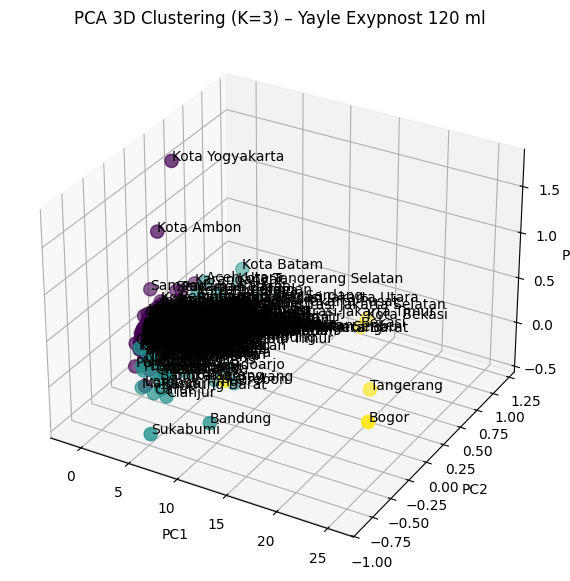


 PCA + KMEANS 3D PRODUK: Yayle Exypnost 200 ml



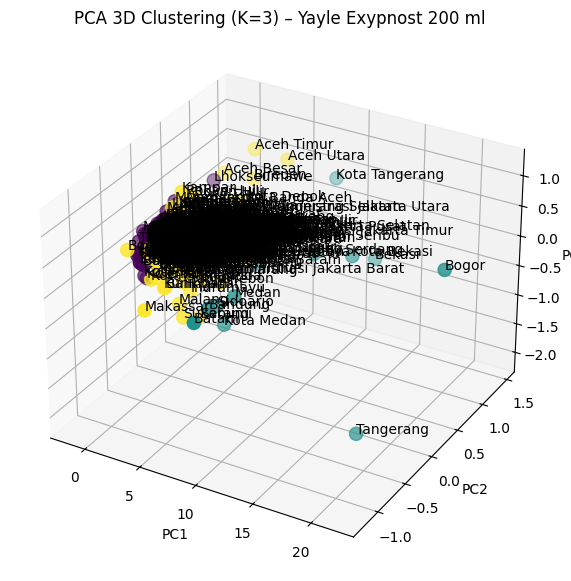

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def pca_kmeans_plot_3d(df_produk, nama_produk, k=3):

    print(f"\n==============================")
    print(f" PCA + KMEANS 3D PRODUK: {nama_produk}")
    print(f"==============================\n")

    # --------------------------------------
    # 1. AGREGASI PER KOTA
    # --------------------------------------
    pivot = df_produk.pivot_table(
        index="kota_normal",
        values=["7","8","9","10","total"],
        aggfunc="sum"
    ).fillna(0)

    X = pivot.values

    # --------------------------------------
    # 2. STANDARDISASI
    # --------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --------------------------------------
    # 3. K-MEANS
    # --------------------------------------
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    pivot["cluster"] = labels

    # --------------------------------------
    # 4. PCA (3D)
    # --------------------------------------
    pca = PCA(n_components=3)
    pcs = pca.fit_transform(X_scaled)

    # --------------------------------------
    # 5. PLOT PCA 3D
    # --------------------------------------
    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection="3d")

    scatter = ax.scatter(pcs[:,0], pcs[:,1], pcs[:,2],
                         c=labels, s=90)

    # label kota
    for i, kota in enumerate(pivot.index):
        ax.text(pcs[i,0], pcs[i,1], pcs[i,2], kota)

    ax.set_title(f"PCA 3D Clustering (K={k}) – {nama_produk}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.show()

    return pivot

hasil_120_3d = pca_kmeans_plot_3d(produk_120, "Yayle Exypnost 120 ml", k=3)
hasil_200_3d = pca_kmeans_plot_3d(produk_200, "Yayle Exypnost 200 ml", k=3)



   ANALISIS PRODUK: Madurasa 120 ml

Uji beberapa nilai K:
K=2  silhouette=0.7812
K=3  silhouette=0.7348
K=4  silhouette=0.6726
K=5  silhouette=0.6654
K=6  silhouette=0.6627

>>> K terbaik untuk Madurasa 120 ml: 2

=== Daftar Kota per Cluster (Top 10) ===

Cluster 0:
- Pandeglang (total=690, produk=Madurasa 120 ml)
- Tasikmalaya (total=667, produk=Madurasa 120 ml)
- Tuban (total=666, produk=Madurasa 120 ml)
- Jakarta Selatan (total=654, produk=Madurasa 120 ml)
- Jombang (total=651, produk=Madurasa 120 ml)
- Kota Administrasi Jakarta Utara (total=630, produk=Madurasa 120 ml)
- Kota Serang (total=611, produk=Madurasa 120 ml)
- Kota Tangerang Selatan (total=604, produk=Madurasa 120 ml)
- Makassar (total=597, produk=Madurasa 120 ml)
- Pekanbaru (total=592, produk=Madurasa 120 ml)

Cluster 1:
- Bogor (total=5135, produk=Madurasa 120 ml)
- Tangerang (total=4037, produk=Madurasa 120 ml)
- Bekasi (total=3041, produk=Madurasa 120 ml)
- Kota Bekasi (total=2919, produk=Madurasa 120 ml)
- Karawan

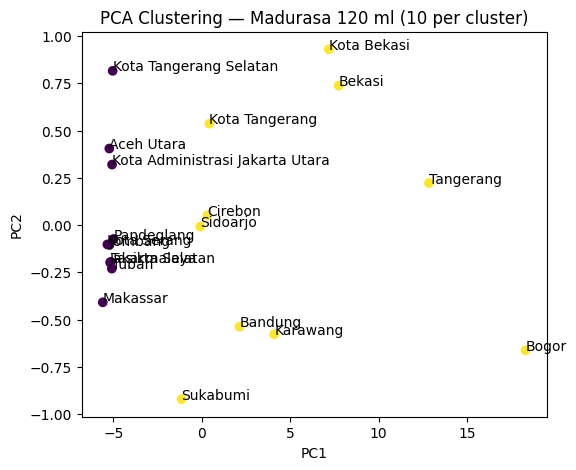


   ANALISIS PRODUK: Madurasa 200 ml

Uji beberapa nilai K:
K=2  silhouette=0.7458
K=3  silhouette=0.6746
K=4  silhouette=0.6088
K=5  silhouette=0.5738
K=6  silhouette=0.5255

>>> K terbaik untuk Madurasa 200 ml: 2

=== Daftar Kota per Cluster (Top 10) ===

Cluster 0:
- Grobogan (total=362, produk=Madurasa 200 ml)
- Langkat (total=349, produk=Madurasa 200 ml)
- Kediri (total=348, produk=Madurasa 200 ml)
- Lamongan (total=345, produk=Madurasa 200 ml)
- Mojokerto (total=341, produk=Madurasa 200 ml)
- Jakarta Selatan (total=337, produk=Madurasa 200 ml)
- Kotawaringin Timur (total=335, produk=Madurasa 200 ml)
- Kutai Timur (total=334, produk=Madurasa 200 ml)
- Demak (total=333, produk=Madurasa 200 ml)
- Bojonegoro (total=329, produk=Madurasa 200 ml)

Cluster 1:
- Bogor (total=2268, produk=Madurasa 200 ml)
- Tangerang (total=1847, produk=Madurasa 200 ml)
- Kota Bekasi (total=1428, produk=Madurasa 200 ml)
- Bekasi (total=1388, produk=Madurasa 200 ml)
- Deli Serdang (total=1098, produk=Madura

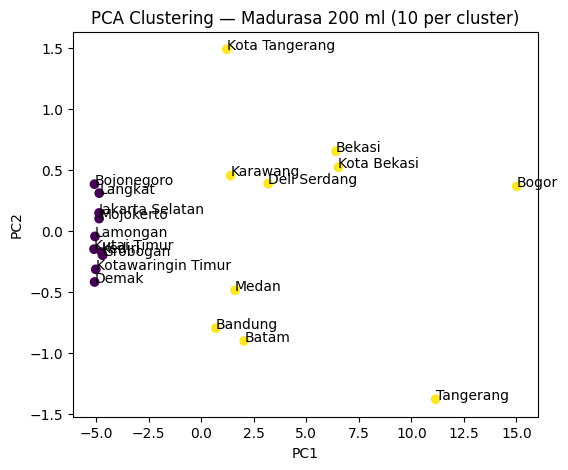

In [71]:
def cluster_per_produk(df_produk, nama_produk):
    print(f"\n==============================")
    print(f"   ANALISIS PRODUK: {nama_produk}")
    print(f"==============================\n")

    X = df_produk[['7','8','9','10','total']]

    # Normalisasi
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # === 3. CARI K OPTIMAL ===
    skor = {}
    print("Uji beberapa nilai K:")
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=42)
        label = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, label)
        skor[k] = sil
        print(f"K={k}  silhouette={sil:.4f}")

    best_k = max(skor, key=skor.get)
    print(f"\n>>> K terbaik untuk {nama_produk}: {best_k}\n")

    # === 4. FINAL MODEL ===
    km = KMeans(n_clusters=best_k, random_state=42)
    df_produk['cluster'] = km.fit_predict(X_scaled)

    # === 5. TAMPILKAN TABEL CLUSTER-KOTA (10 WILAYAH SAJA) ===
    print("=== Daftar Kota per Cluster (Top 10) ===")
    for c in sorted(df_produk['cluster'].unique()):
        print(f"\nCluster {c}:")
        subset = df_produk[df_produk['cluster'] == c]

        # ambil 10 data teratas berdasarkan total terbesar
        subset_top10 = subset.sort_values('total', ascending=False).head(10)

        for _, r in subset_top10.iterrows():
            print(f"- {r['kota_normal']} (total={r['total']}, produk={r['produk']})")

    # === 6. PCA PLOT — TAMPIL 10 WILAYAH PER CLUSTER ===
    df_vis = (
        df_produk
        .sort_values(['cluster','total'], ascending=[True, False])
        .groupby('cluster')
        .head(10)
        .copy()
    )

    X_vis = scaler.transform(df_vis[['7','8','9','10','total']])

    pca = PCA(n_components=2)
    pc = pca.fit_transform(X_vis)

    plt.figure(figsize=(6,5))
    plt.scatter(pc[:,0], pc[:,1], c=df_vis['cluster'])

    for i, txt in enumerate(df_vis['kota_normal']):
        plt.annotate(txt, (pc[i,0], pc[i,1]))

    plt.title(f"PCA Clustering — {nama_produk} (10 per cluster)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    return df_produk


# === 7. PISAHKAN PER PRODUK ===
produk_120 = df[df['produk'] == "Madurasa 120 ml"].copy()
produk_200 = df[df['produk'] == "Madurasa 200 ml"].copy()

# === 8. JALANKAN KEDUA ANALISIS ===
hasil_120 = cluster_per_produk(produk_120, "Madurasa 120 ml")
hasil_200 = cluster_per_produk(produk_200, "Madurasa 200 ml")


In [58]:
pip install tabulate


In [67]:
from tabulate import tabulate

def pretty_print(df, title):
    print(f"\n=== {title} ===")
    print(tabulate(
        df[["kota_normal","produk","7","8","9","10"]],
        headers="keys",
        tablefmt="github",
        showindex=False
    ))

pretty_print(df_rising_120, "WILAYAH RISING – PRODUK 120 ml")
pretty_print(df_rising_200, "WILAYAH RISING – PRODUK 200 ml")



=== WILAYAH RISING – PRODUK 120 ml ===
| kota_normal     | produk          |   7 |   8 |   9 |   10 |
|-----------------|-----------------|-----|-----|-----|------|
| Kepulauan Yapen | Madurasa 120 ml |   0 |   0 |   0 |    2 |
| Kota Melaka     | Madurasa 120 ml |   0 |   1 |   1 |    4 |
| Kutha Tangerang | Madurasa 120 ml |   0 |   0 |   0 |    2 |
| Mappi           | Madurasa 120 ml |   0 |   0 |   1 |    2 |
| Nabire          | Madurasa 120 ml |   0 |   0 |   0 |    2 |
| Pulau Taliabu   | Madurasa 120 ml |   0 |   0 |   1 |    2 |

=== WILAYAH RISING – PRODUK 200 ml ===
| kota_normal             | produk          |   7 |   8 |   9 |   10 |
|-------------------------|-----------------|-----|-----|-----|------|
| Bolaang Mongondow Timur | Madurasa 200 ml |   1 |   2 |   2 |    2 |
| Kampobalano             | Madurasa 200 ml |   0 |   0 |   0 |    1 |
| Keerom                  | Madurasa 200 ml |   0 |   1 |   1 |    1 |
| Kota Adm Jakarta Pusat  | Madurasa 200 ml |   0 |   3 |   3

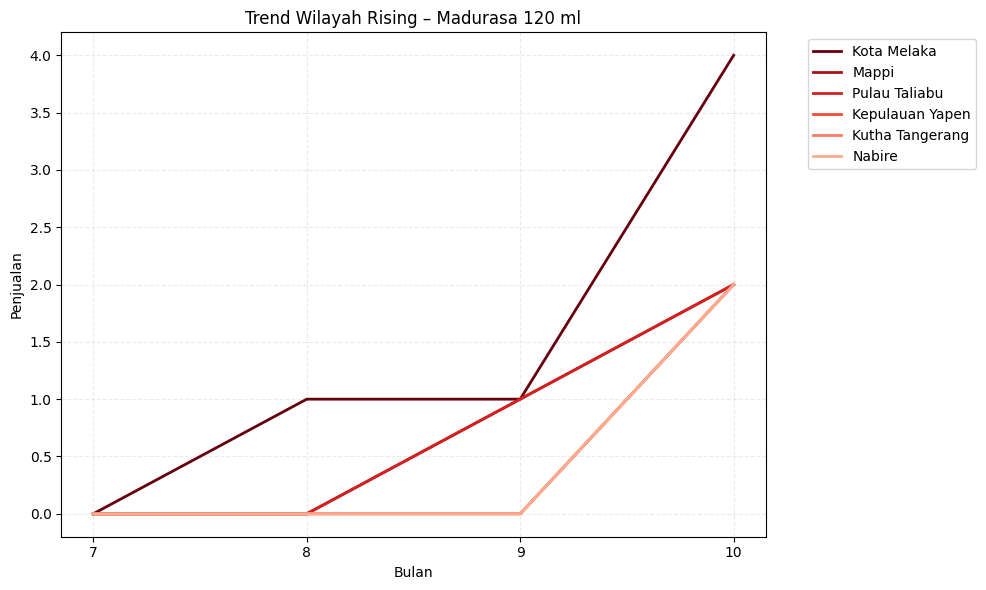

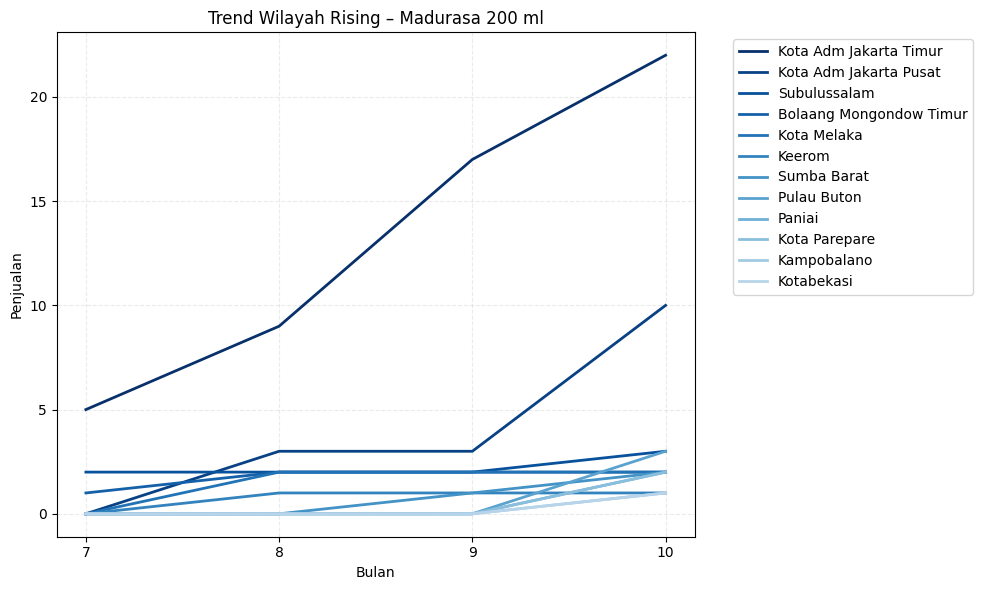

In [57]:
def plot_rising_simple(data, title, produk):
    plt.figure(figsize=(10,6))

    # Pilih colormap
    if produk == "Madurasa 120 ml":
        base_cmap = plt.cm.Reds
    else:
        base_cmap = plt.cm.Blues

    # PENGURUTAN UTAMA (TOTAL TERTINGGI = PALING GELAP)
    data_sorted = data.sort_values(by="total", ascending=False).reset_index(drop=True)
    n = len(data_sorted)

    # AMBIL RENTANG WARNA 0.3 → 1.0 AGAR TIDAK PUTIH
    colors = [base_cmap(0.3 + 0.7*(i/(n-1))) for i in range(n)]
    colors = colors[::-1]   # nilai terbesar = gelap

    lines = []
    labels = []

    for i, (_, row) in enumerate(data_sorted.iterrows()):
        y = row[bulan_cols]
        line, = plt.plot(
            bulan_cols, y,
            color=colors[i],
            linewidth=2
        )
        lines.append(line)
        labels.append(row["kota_normal"])

    plt.title(f"Trend Wilayah Rising – {title}")
    plt.xlabel("Bulan")
    plt.ylabel("Penjualan")
    plt.grid(True, linestyle="--", alpha=0.25)

    plt.legend(lines, labels, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# Split data
df_120 = df_rising[df_rising["produk"] == "Madurasa 120 ml"]
df_200 = df_rising[df_rising["produk"] == "Madurasa 200 ml"]

# Plot
plot_rising_simple(df_120, "Madurasa 120 ml", "Madurasa 120 ml")
plot_rising_simple(df_200, "Madurasa 200 ml", "Madurasa 200 ml")
